In [7]:
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp

# Dodanie ścieżki do zad2 dla solverów
sys.path.append(os.path.abspath(os.path.join('..', 'zad2')))

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

OUTDIR = Path("results")
OUTDIR.mkdir(exist_ok=True)

# Parametry "Prawdziwe" (Ground Truth) - bardziej stromy przypadek
TRUE_PARAMS = {
    'D': 0.02,
    'p': 0.05,
    'q': 4.0
}
T_END = 5.0
NX = 150
DT = 5e-4

# Konfiguracja szumu / trudności
NOISE_LEVEL = 0.05
NOISE_KIND = "gaussian_mixture"  # gaussian, laplace, gaussian_mixture
PROC_SIGMA = 0.02  # siła szumu procesowego w supermodelu ODE
COUPLING_STRENGTH = 2.0
N_DATA_SUPERNET = 400
N_COL_SUPERNET = 6000
EPOCHS_SUPERNET = 2000
LAMBDA_COUPLE = 0.5


Using device: cpu


## 1. Generowanie Danych Ground Truth (PDE)

In [8]:
def add_noise(u, kind, level, rng):
    scale = level * np.maximum(1e-3, np.abs(u))
    if kind == "gaussian":
        noise = rng.normal(0.0, scale)
    elif kind == "laplace":
        noise = rng.laplace(0.0, scale)
    elif kind == "gaussian_mixture":
        comp = rng.choice([0, 1, 2], size=u.shape, p=[0.7, 0.2, 0.1])
        noise = np.where(
            comp == 0,
            rng.normal(0.0, scale),
            np.where(
                comp == 1,
                rng.laplace(0.0, 1.5 * scale),
                rng.normal(0.0, 3.0 * scale),
            ),
        )
    else:
        raise ValueError(f"Unsupported noise kind: {kind}")
    return u + noise


def generate_pde_data():
    try:
        from solvers import _neumann_laplacian, reaction, initial_condition
        import scipy.sparse as sp
        import scipy.sparse.linalg as spla

        nx = NX
        dt = DT
        tend = T_END
        D = TRUE_PARAMS['D']
        p = TRUE_PARAMS['p']
        q = TRUE_PARAMS['q']

        dx = 1.0 / (nx - 1)
        x = np.linspace(0, 1, nx)
        u = initial_condition(nx, dx, kind='localized')

        A = _neumann_laplacian(nx, dx)
        M_l = sp.eye(nx) - 0.5 * dt * D * A
        M_r = sp.eye(nx) + 0.5 * dt * D * A

        nsteps = int(np.ceil(tend / dt))
        u_all = [u.copy()]
        t_all = [0.0]
        current_t = 0.0

        for n in range(nsteps):
            Ru = reaction(u, p, q)
            rhs = M_r.dot(u) + dt * Ru
            u = spla.spsolve(M_l, rhs)
            current_t += dt
            if (n + 1) % 10 == 0:
                u_all.append(u.copy())
                t_all.append(current_t)

        return x, np.array(t_all), np.array(u_all).T
    except ImportError:
        print("Brak modułu solvers.py. Upewnij się, że jesteś w odpowiednim katalogu.")
        return None, None, None


x_true, t_true, u_true_clean = generate_pde_data()
rng_noise = np.random.default_rng(321)
u_true_noisy = add_noise(u_true_clean, NOISE_KIND, NOISE_LEVEL, rng_noise)
u_true_mean = np.mean(u_true_clean, axis=0)  # Średnia przestrzenna dla porównania z ODE

print(f"Dane PDE wygenerowane: {u_true_clean.shape}, z szumem: {u_true_noisy.shape}")


Dane PDE wygenerowane: (150, 1001), z szumem: (150, 1001)


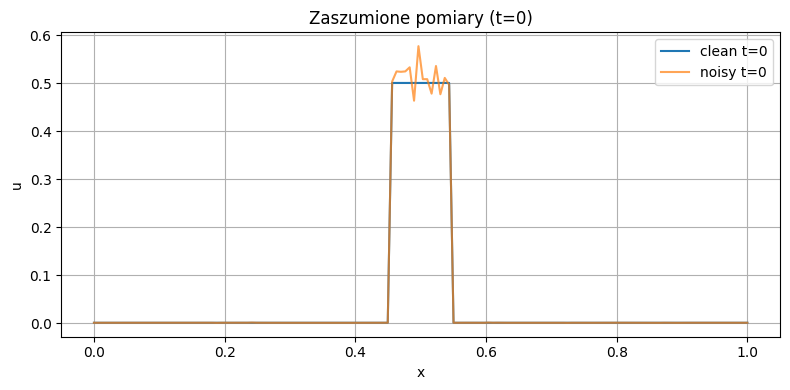

In [9]:
# Podgląd szumu dla danych PDE
if x_true is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(x_true, u_true_clean[:, 0], label='clean t=0')
    plt.plot(x_true, u_true_noisy[:, 0], label='noisy t=0', alpha=0.7)
    plt.title('Zaszumione pomiary (t=0)')
    plt.xlabel('x')
    plt.ylabel('u')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTDIR / 'zad7_noise_slice_t0.png')
    plt.show()


## 2. Supermodel ODE

Stworzymy zespół 3 modeli ODE z zaburzonymi parametrami. Modele będą sprzężone (coupled) poprzez człon relaksacyjny dążący do średniej zespołu (Nudging).

Równanie $i$-tego modelu:
$$ \frac{dU_i}{dt} = f(U_i, p_i, q_i) + C \cdot (\bar{U} - U_i) $$
gdzie $\bar{U} = \frac{1}{N} \sum U_j$.

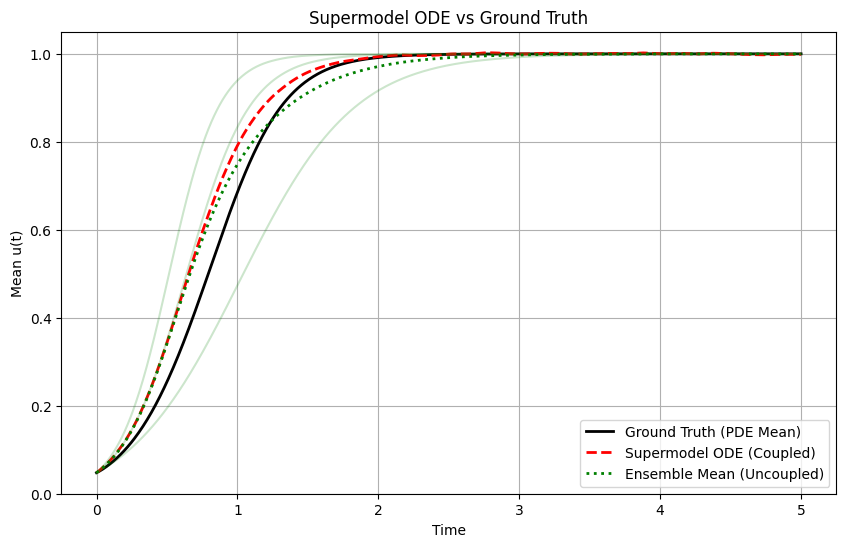

In [10]:
# Definicja zaburzonych parametrów (większe rozrzuty)
models_params = [
    {'p': TRUE_PARAMS['p'] * 0.6, 'q': TRUE_PARAMS['q'] * 1.4},
    {'p': TRUE_PARAMS['p'] * 1.4, 'q': TRUE_PARAMS['q'] * 0.6},
    {'p': TRUE_PARAMS['p'] * 0.8, 'q': TRUE_PARAMS['q'] * 1.1},
]

C_coupling = COUPLING_STRENGTH  # Siła sprzężenia (mniejsza, by dopuścić rozjazd)

# Szum procesowy (deterministyczna trajektoria do solve_ivp)
proc_noise_paths = np.random.normal(0.0, PROC_SIGMA, size=(len(models_params), len(t_true)))


def supermodel_ode_system(t, y):
    # y to wektor [U1, U2, U3]
    U = y
    U_mean = np.mean(U)

    dydt = []
    for i, params in enumerate(models_params):
        p = params['p']
        q = params['q']
        u_val = U[i]

        # Dynamika własna
        f_val = (p + q * u_val) * (1 - u_val)

        # Sprzężenie
        coupling = C_coupling * (U_mean - u_val)

        # Wymuszenie szumem procesowym (stała trajektoria w czasie)
        noise_force = np.interp(t, t_true, proc_noise_paths[i])

        dydt.append(f_val + coupling + noise_force)

    return dydt

# Warunek początkowy (średnia z PDE)
u0_val = u_true_mean[0]
y0 = [u0_val, u0_val, u0_val]

# Rozwiązanie Supermodelu
sol_super = solve_ivp(supermodel_ode_system, [t_true[0], t_true[-1]], y0, t_eval=t_true)
u_super_all = sol_super.y  # (3, NT)
u_super_mean = np.mean(u_super_all, axis=0)

# Rozwiązanie modeli niezależnych (bez sprzężenia) dla porównania
u_indep_all = []
for params in models_params:
    def ode_single(t, u):
        return (params['p'] + params['q'] * u) * (1 - u)
    sol = solve_ivp(ode_single, [t_true[0], t_true[-1]], [u0_val], t_eval=t_true)
    u_indep_all.append(sol.y.flatten())
u_indep_all = np.array(u_indep_all)
u_indep_mean = np.mean(u_indep_all, axis=0)

# Wizualizacja ODE
plt.figure(figsize=(10, 6))
plt.plot(t_true, u_true_mean, 'k-', linewidth=2, label='Ground Truth (PDE Mean)')
plt.plot(t_true, u_super_mean, 'r--', linewidth=2, label='Supermodel ODE (Coupled)')
plt.plot(t_true, u_indep_mean, 'g:', linewidth=2, label='Ensemble Mean (Uncoupled)')

for i in range(3):
    plt.plot(t_true, u_indep_all[i], 'g-', alpha=0.2)

plt.legend()
plt.title('Supermodel ODE vs Ground Truth')
plt.xlabel('Time')
plt.ylabel('Mean u(t)')
plt.grid(True)
plt.savefig(OUTDIR / 'supermodel_ode_results.png')
plt.show()


## 3. SuperNet PINN

Stworzymy zespół 3 sieci PINN. Każda sieć będzie uczona z użyciem "fizyki" opartej na zaburzonych parametrach (takich jak w Supermodelu ODE). Dodatkowo wprowadzimy **Coupling Loss**, który karze odchylenia wyjścia każdej sieci od średniej wyjścia całego zespołu.

$$ L_{total} = \sum_{i=1}^3 (L_{data, i} + L_{physics, i}) + \lambda_{couple} \sum_{i=1}^3 ||u_i - \bar{u}||^2 $$

In [11]:
# Przygotowanie danych treningowych (wspólne dla wszystkich sieci)
X, T = np.meshgrid(x_true, t_true)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
u_flat_clean = u_true_clean.T.flatten()[:, None]
u_flat_noisy = u_true_noisy.T.flatten()[:, None]

# Losowe punkty pomiarowe (zaszumione dane)
N_data = N_DATA_SUPERNET
rng_train = np.random.default_rng(777)
idx = rng_train.choice(X_flat.shape[0], N_data, replace=False)
X_train = np.hstack((X_flat[idx], T_flat[idx]))
u_train = u_flat_noisy[idx]

# Punkty kolokacji (więcej, by wymusić fizykę)
N_col = N_COL_SUPERNET
rng_col = np.random.default_rng(888)
X_col = rng_col.uniform(0, 1, (N_col, 1))
T_col = rng_col.uniform(0, T_END, (N_col, 1))
XT_col = np.hstack((X_col, T_col))

# Tensory
X_u_train = torch.tensor(X_train, dtype=torch.float32).to(device)
u_train_tensor = torch.tensor(u_train, dtype=torch.float32).to(device)
X_f_train = torch.tensor(XT_col, dtype=torch.float32).to(device)


class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 1)
        )
    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)


def physics_loss_pinn(model, x, t, params):
    x.requires_grad = True
    t.requires_grad = True
    u = model(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    D = TRUE_PARAMS['D']  # Zakładamy, że D jest znane lub stałe, zaburzamy p i q
    p = params['p']
    q = params['q']

    f = u_t - D * u_xx - (p + q * u) * (1 - u)
    return torch.mean(f ** 2)


# Inicjalizacja zespołu sieci
models = [PINN().to(device) for _ in range(3)]
optimizers = [torch.optim.Adam(m.parameters(), lr=1e-3) for m in models]

epochs = EPOCHS_SUPERNET
lambda_couple = LAMBDA_COUPLE

loss_history = []

print("Rozpoczynam trening SuperNet...")
start_time = time.time()

for epoch in range(epochs):
    # Zerowanie gradientów
    for opt in optimizers:
        opt.zero_grad()

    # Forward pass dla wszystkich modeli
    x_data = X_u_train[:, 0:1]
    t_data = X_u_train[:, 1:2]

    u_preds_data = [m(x_data, t_data) for m in models]

    # Data Loss (każdy model uczy się danych)
    losses_data = [torch.mean((up - u_train_tensor) ** 2) for up in u_preds_data]

    # Physics Loss (każdy model ma swoje zaburzone parametry)
    x_col = X_f_train[:, 0:1]
    t_col = X_f_train[:, 1:2]

    losses_phy = []
    u_preds_col = []  # Do couplingu w punktach kolokacji

    for i, m in enumerate(models):
        l_phy = physics_loss_pinn(m, x_col, t_col, models_params[i])
        losses_phy.append(l_phy)
        u_preds_col.append(m(x_col, t_col))

    # Coupling Loss (w punktach kolokacji)
    # Obliczamy średnią predykcję zespołu
    u_stack = torch.stack(u_preds_col, dim=0)
    u_mean = torch.mean(u_stack, dim=0)

    # Loss to odległość każdego modelu od średniej
    loss_couple = torch.mean((u_stack - u_mean) ** 2)

    # Sumowanie i backward
    total_loss = 0.0
    for i in range(3):
        loss_i = losses_data[i] + losses_phy[i] + lambda_couple * loss_couple
        loss_i.backward(retain_graph=True)  # retain_graph potrzebne bo współdzielimy loss_couple
        total_loss += loss_i.item()

    for opt in optimizers:
        opt.step()

    loss_history.append(total_loss)

    if (epoch + 1) % 400 == 0:
        print(
            f"Epoch {epoch+1}, Total Loss: {total_loss:.6f}, "
            f"Data: {[ld.item() for ld in losses_data]}, Phy: {[lp.item() for lp in losses_phy]}, "
            f"Couple: {loss_couple.item():.6f}"
        )

print(f"Trening zakończony w {time.time() - start_time:.2f}s")


Rozpoczynam trening SuperNet...
Epoch 400, Total Loss: 1.693715, Data: [0.7044799327850342, 0.021722402423620224, 0.6619505286216736], Phy: [0.035365257412195206, 0.01153348758816719, 0.06553539633750916], Couple: 0.128752
Epoch 800, Total Loss: 1.007128, Data: [0.6936926245689392, 0.013713935390114784, 0.010361985303461552], Phy: [0.048198018223047256, 0.0018400764092803001, 0.011391893029212952], Couple: 0.151953
Epoch 1200, Total Loss: 0.992812, Data: [0.6922540068626404, 0.014134185388684273, 0.011072983965277672], Phy: [0.04900947958230972, 0.0017953857313841581, 0.0014389752177521586], Couple: 0.148738
Epoch 1600, Total Loss: 0.991870, Data: [0.6940948963165283, 0.013974983245134354, 0.011028766632080078], Phy: [0.04606795683503151, 0.0018194274744018912, 0.00132140947971493], Couple: 0.149042
Epoch 2000, Total Loss: 0.990652, Data: [0.6888921856880188, 0.013586479239165783, 0.010876641608774662], Phy: [0.05236760526895523, 0.001894838293083012, 0.0013423608615994453], Couple: 0.

## 4. Ewaluacja i Porównanie

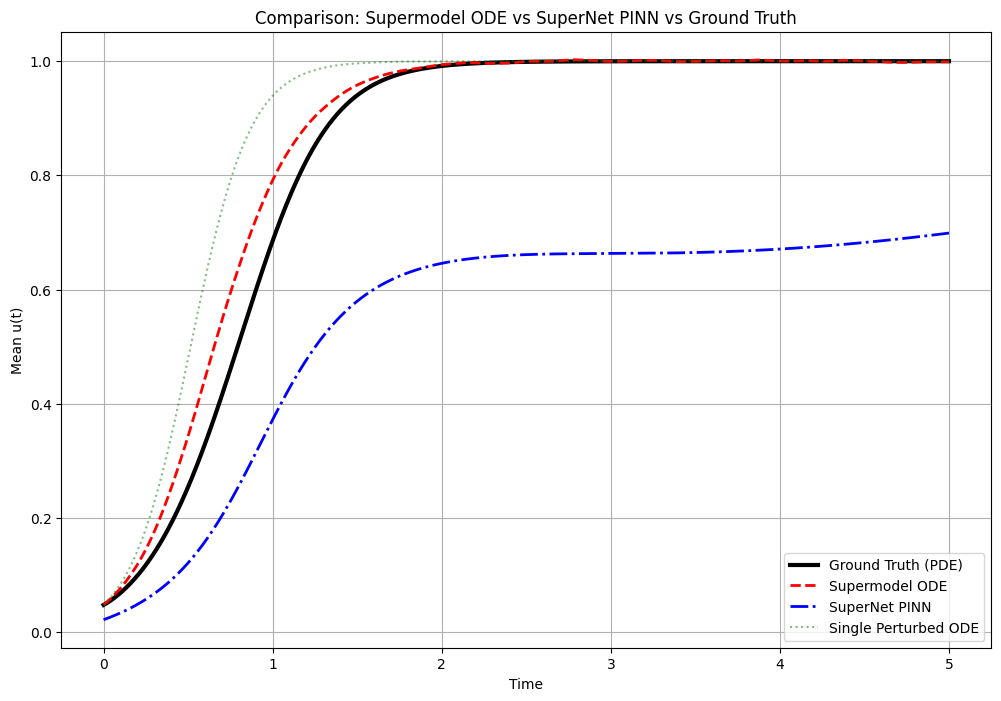

RMSE Supermodel ODE: 0.045112
RMSE SuperNet PINN: 0.309868
RMSE Single Perturbed ODE: 0.111640


In [12]:
# Ewaluacja SuperNet na siatce
X_grid, T_grid = np.meshgrid(x_true, t_true)
X_flat_eval = X_grid.flatten()[:, None]
T_flat_eval = T_grid.flatten()[:, None]

x_eval = torch.tensor(X_flat_eval, dtype=torch.float32).to(device)
t_eval = torch.tensor(T_flat_eval, dtype=torch.float32).to(device)

u_preds_eval = []
with torch.no_grad():
    for m in models:
        u_preds_eval.append(m(x_eval, t_eval).cpu().numpy())

u_supernet_mean_flat = np.mean(np.array(u_preds_eval), axis=0)
u_supernet_grid = u_supernet_mean_flat.reshape(X_grid.shape)

# Obliczanie średniej przestrzennej dla SuperNet
u_supernet_spatial_mean = np.mean(u_supernet_grid, axis=1)

# Wykres porównawczy wszystkich podejść
plt.figure(figsize=(12, 8))

# 1. Ground Truth
plt.plot(t_true, u_true_mean, 'k-', linewidth=3, label='Ground Truth (PDE)')

# 2. Supermodel ODE
plt.plot(t_true, u_super_mean, 'r--', linewidth=2, label='Supermodel ODE')

# 3. SuperNet PINN
plt.plot(t_true, u_supernet_spatial_mean, 'b-.', linewidth=2, label='SuperNet PINN')

# 4. Pojedynczy zaburzony model ODE (dla kontekstu)
plt.plot(t_true, u_indep_all[0], 'g:', alpha=0.5, label='Single Perturbed ODE')

plt.title('Comparison: Supermodel ODE vs SuperNet PINN vs Ground Truth')
plt.xlabel('Time')
plt.ylabel('Mean u(t)')
plt.legend()
plt.grid(True)
plt.savefig(OUTDIR / 'supermodel_vs_supernet.png')
plt.show()

# Obliczenie błędów RMSE dla średnich trajektorii
rmse_ode = np.sqrt(np.mean((u_true_mean - u_super_mean)**2))
rmse_pinn = np.sqrt(np.mean((u_true_mean - u_supernet_spatial_mean)**2))
rmse_single = np.sqrt(np.mean((u_true_mean - u_indep_all[0])**2))

print(f"RMSE Supermodel ODE: {rmse_ode:.6f}")
print(f"RMSE SuperNet PINN: {rmse_pinn:.6f}")
print(f"RMSE Single Perturbed ODE: {rmse_single:.6f}")
